In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv(r"C:\Users\lenovo\OneDrive\Desktop\Folder\daily-python-data-lab\04_machine_learning\On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2026_1.csv", low_memory=False)

In [3]:
print(df.shape)

(544003, 110)


In [4]:
df.columns.tolist()

['Year',
 'Quarter',
 'Month',
 'DayofMonth',
 'DayOfWeek',
 'FlightDate',
 'Reporting_Airline',
 'DOT_ID_Reporting_Airline',
 'IATA_CODE_Reporting_Airline',
 'Tail_Number',
 'Flight_Number_Reporting_Airline',
 'OriginAirportID',
 'OriginAirportSeqID',
 'OriginCityMarketID',
 'Origin',
 'OriginCityName',
 'OriginState',
 'OriginStateFips',
 'OriginStateName',
 'OriginWac',
 'DestAirportID',
 'DestAirportSeqID',
 'DestCityMarketID',
 'Dest',
 'DestCityName',
 'DestState',
 'DestStateFips',
 'DestStateName',
 'DestWac',
 'CRSDepTime',
 'DepTime',
 'DepDelay',
 'DepDelayMinutes',
 'DepDel15',
 'DepartureDelayGroups',
 'DepTimeBlk',
 'TaxiOut',
 'WheelsOff',
 'WheelsOn',
 'TaxiIn',
 'CRSArrTime',
 'ArrTime',
 'ArrDelay',
 'ArrDelayMinutes',
 'ArrDel15',
 'ArrivalDelayGroups',
 'ArrTimeBlk',
 'Cancelled',
 'CancellationCode',
 'Diverted',
 'CRSElapsedTime',
 'ActualElapsedTime',
 'AirTime',
 'Flights',
 'Distance',
 'DistanceGroup',
 'CarrierDelay',
 'WeatherDelay',
 'NASDelay',
 'SecurityD

In [5]:
df.head()

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,DOT_ID_Reporting_Airline,IATA_CODE_Reporting_Airline,Tail_Number,...,Div4TailNum,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum,Unnamed: 109
0,2026,1,1,1,4,2026-01-01,AA,19805,AA,N111ZM,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026,1,1,2,5,2026-01-02,AA,19805,AA,N109NN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026,1,1,3,6,2026-01-03,AA,19805,AA,N101NN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026,1,1,4,7,2026-01-04,AA,19805,AA,N117AN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026,1,1,5,1,2026-01-05,AA,19805,AA,N104NN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.tail()

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,DOT_ID_Reporting_Airline,IATA_CODE_Reporting_Airline,Tail_Number,...,Div4TailNum,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum,Unnamed: 109
543998,2026,1,1,5,1,2026-01-05,UA,19977,UA,N77573,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
543999,2026,1,1,5,1,2026-01-05,UA,19977,UA,N453UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
544000,2026,1,1,5,1,2026-01-05,UA,19977,UA,N14704,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
544001,2026,1,1,5,1,2026-01-05,UA,19977,UA,N16701,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
544002,2026,1,1,5,1,2026-01-05,UA,19977,UA,N811UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df.shape

(544003, 110)

In [8]:
df.columns

Index(['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'FlightDate',
       'Reporting_Airline', 'DOT_ID_Reporting_Airline',
       'IATA_CODE_Reporting_Airline', 'Tail_Number',
       ...
       'Div4TailNum', 'Div5Airport', 'Div5AirportID', 'Div5AirportSeqID',
       'Div5WheelsOn', 'Div5TotalGTime', 'Div5LongestGTime', 'Div5WheelsOff',
       'Div5TailNum', 'Unnamed: 109'],
      dtype='object', length=110)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 544003 entries, 0 to 544002
Columns: 110 entries, Year to Unnamed: 109
dtypes: float64(70), int64(21), object(19)
memory usage: 456.5+ MB


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,544003.0,2026.000000,0.000000,2026.0,2026.0,2026.0,2026.0,2026.0
Quarter,544003.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
Month,544003.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
DayofMonth,544003.0,15.774599,9.001972,1.0,8.0,16.0,24.0,31.0
DayOfWeek,544003.0,4.109680,1.952692,1.0,2.0,4.0,6.0,7.0
...,...,...,...,...,...,...,...,...
Div5TotalGTime,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Div5LongestGTime,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Div5WheelsOff,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Div5TailNum,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df.isnull().sum()

Year                     0
Quarter                  0
Month                    0
DayofMonth               0
DayOfWeek                0
                     ...  
Div5TotalGTime      544003
Div5LongestGTime    544003
Div5WheelsOff       544003
Div5TailNum         544003
Unnamed: 109        544003
Length: 110, dtype: int64

In [12]:
(df.isnull().mean()*100).sort_values(ascending=False)

Unnamed: 109        100.0
Div4LongestGTime    100.0
Div3Airport         100.0
Div3WheelsOn        100.0
Div3TotalGTime      100.0
                    ...  
DestStateFips         0.0
DestState             0.0
DestCityName          0.0
Dest                  0.0
DistanceGroup         0.0
Length: 110, dtype: float64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.dtypes

Year                  int64
Quarter               int64
Month                 int64
DayofMonth            int64
DayOfWeek             int64
                     ...   
Div5TotalGTime      float64
Div5LongestGTime    float64
Div5WheelsOff       float64
Div5TailNum         float64
Unnamed: 109        float64
Length: 110, dtype: object

In [15]:
for col in df.columns:
    print(col)
    print(df[col].nunique())
    print("-"*40)

Year
1
----------------------------------------
Quarter
1
----------------------------------------
Month
1
----------------------------------------
DayofMonth
31
----------------------------------------
DayOfWeek
7
----------------------------------------
FlightDate
31
----------------------------------------
Reporting_Airline
13
----------------------------------------
DOT_ID_Reporting_Airline
13
----------------------------------------
IATA_CODE_Reporting_Airline
13
----------------------------------------
Tail_Number
5702
----------------------------------------
Flight_Number_Reporting_Airline
6307
----------------------------------------
OriginAirportID
341
----------------------------------------
OriginAirportSeqID
341
----------------------------------------
OriginCityMarketID
318
----------------------------------------
Origin
341
----------------------------------------
OriginCityName
335
----------------------------------------
OriginState
52
----------------------------------

In [16]:
df.drop(columns=[
    'Tail_Number'
], inplace=True)

In [17]:
df['FlightDate']=pd.to_datetime(df['FlightDate'])

In [18]:
df['Year']=df['FlightDate'].dt.year
df['Month']=df['FlightDate'].dt.month
df['Day']=df['FlightDate'].dt.day
df['Weekday']=df['FlightDate'].dt.day_name()

In [19]:
df['DepHour']=df['CRSDepTime']//100

In [20]:
df['ArrHour']=df['CRSArrTime']//100

In [21]:
num_cols=df.describe().columns
num_cols

Index(['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'FlightDate',
       'DOT_ID_Reporting_Airline', 'Flight_Number_Reporting_Airline',
       'OriginAirportID', 'OriginAirportSeqID', 'OriginCityMarketID',
       'OriginStateFips', 'OriginWac', 'DestAirportID', 'DestAirportSeqID',
       'DestCityMarketID', 'DestStateFips', 'DestWac', 'CRSDepTime', 'DepTime',
       'DepDelay', 'DepDelayMinutes', 'DepDel15', 'DepartureDelayGroups',
       'TaxiOut', 'WheelsOff', 'WheelsOn', 'TaxiIn', 'CRSArrTime', 'ArrTime',
       'ArrDelay', 'ArrDelayMinutes', 'ArrDel15', 'ArrivalDelayGroups',
       'Cancelled', 'Diverted', 'CRSElapsedTime', 'ActualElapsedTime',
       'AirTime', 'Flights', 'Distance', 'DistanceGroup', 'CarrierDelay',
       'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay',
       'FirstDepTime', 'TotalAddGTime', 'LongestAddGTime',
       'DivAirportLandings', 'DivReachedDest', 'DivActualElapsedTime',
       'DivArrDelay', 'DivDistance', 'Div1AirportID', 'D

In [22]:
Q1=df['ArrDelay'].quantile(0.25)
Q3=df['ArrDelay'].quantile(0.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

df=df[(df.ArrDelay>=lower)&(df.ArrDelay<=upper)]

<Axes: xlabel='ArrDelay', ylabel='Count'>

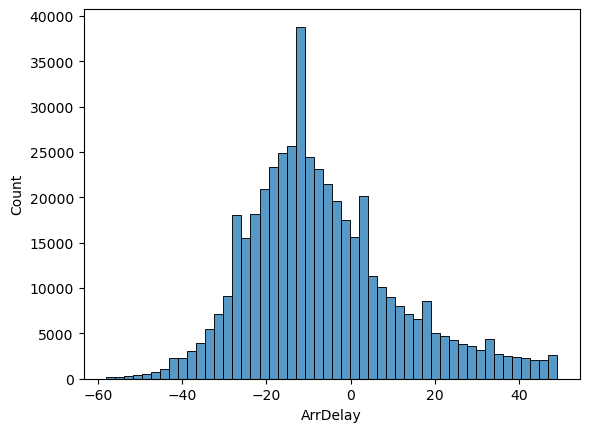

In [23]:
sns.histplot(df['ArrDelay'],bins=50)

<Axes: >

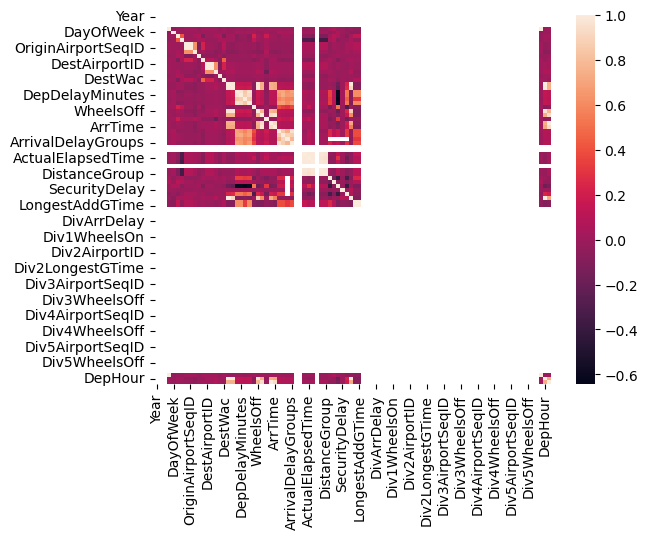

In [24]:
sns.heatmap(df.corr(numeric_only=True))

In [25]:
y=df['ArrDelay']

In [26]:
X=df.drop(columns=['ArrDelay'])

In [27]:
num_features=X.select_dtypes(
    include=np.number
).columns

In [28]:
cat_features=X.select_dtypes(
    include='object'
).columns

In [29]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [30]:
model = LinearRegression()

In [31]:
# model.fit(X_train, y_train)

In [32]:
df['FlightDate'] = pd.to_datetime(df['FlightDate'])

df['Year'] = df['FlightDate'].dt.year
df['Month'] = df['FlightDate'].dt.month
df['Day'] = df['FlightDate'].dt.day
df['DayOfWeek'] = df['FlightDate'].dt.dayofweek

In [33]:
df.drop('FlightDate', axis=1, inplace=True)

In [34]:
df = pd.get_dummies(df, drop_first=True)

In [35]:
X = df.drop('ArrDelay', axis=1)
y = df['ArrDelay']

In [36]:
model = LinearRegression()

In [38]:
# model.fit(X_train, y_train)

In [39]:
df.shape

(470108, 1712)

In [40]:
X.shape

(470108, 1711)

In [41]:
target_cols = ["ArrDelay","ArrDelayMinutes","ArrDel15","ArrivalDelayGroups"]

In [42]:
leakage_cols = ["DepTime","DepDelay","DepDelayMinutes","DepDel15","DepartureDelayGroups",
                "TaxiOut","WheelsOff","WheelsOn","TaxiIn","ArrTime","ActualElapsedTime","AirTime",
                "CarrierDelay","WeatherDelay","NASDelay","SecurityDelay","LateAircraftDelay"]

In [43]:
diversion_cols = [
    "FirstDepTime",
    "TotalAddGTime",
    "LongestAddGTime",
    "DivAirportLandings",
    "DivReachedDest",
    "DivActualElapsedTime",
    "DivArrDelay",
    "DivDistance",
    "Div1Airport","Div1AirportID","Div1AirportSeqID","Div1WheelsOn",
    "Div1TotalGTime","Div1LongestGTime","Div1WheelsOff","Div1TailNum",
    "Div2Airport","Div2AirportID","Div2AirportSeqID","Div2WheelsOn",
    "Div2TotalGTime","Div2LongestGTime","Div2WheelsOff","Div2TailNum",
    "Div3Airport","Div3AirportID","Div3AirportSeqID","Div3WheelsOn",
    "Div3TotalGTime","Div3LongestGTime","Div3WheelsOff","Div3TailNum",
    "Div4Airport","Div4AirportID","Div4AirportSeqID","Div4WheelsOn",
    "Div4TotalGTime","Div4LongestGTime","Div4WheelsOff","Div4TailNum",
    "Div5Airport","Div5AirportID","Div5AirportSeqID","Div5WheelsOn",
    "Div5TotalGTime","Div5LongestGTime","Div5WheelsOff","Div5TailNum"
]

In [44]:
id_cols = [
    "FlightDate",
    "Tail_Number",
    "Flight_Number_Reporting_Airline",
    "DOT_ID_Reporting_Airline",
    "OriginAirportSeqID",
    "DestAirportSeqID",
    "OriginAirportID",
    "DestAirportID",
    "OriginCityMarketID",
    "DestCityMarketID",
    "Unnamed: 109"
]

In [45]:
drop_cols = target_cols + leakage_cols + diversion_cols + id_cols

X = df.drop(columns=drop_cols, errors="ignore")

In [46]:
y = df['ArrDelay']

In [47]:
X.columns

Index(['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek',
       'OriginStateFips', 'OriginWac', 'DestStateFips', 'DestWac',
       'CRSDepTime',
       ...
       'ArrTimeBlk_2000-2059', 'ArrTimeBlk_2100-2159', 'ArrTimeBlk_2200-2259',
       'ArrTimeBlk_2300-2359', 'Weekday_Monday', 'Weekday_Saturday',
       'Weekday_Sunday', 'Weekday_Thursday', 'Weekday_Tuesday',
       'Weekday_Wednesday'],
      dtype='object', length=1638)

In [48]:
X.isnull().sum().sort_values(ascending=False)

Year                              0
Dest_RHI                          0
Dest_SAF                          0
Dest_RSW                          0
Dest_RST                          0
                                 ..
OriginCityName_Kearney, NE        0
OriginCityName_Kansas City, MO    0
OriginCityName_Kalispell, MT      0
OriginCityName_Kalamazoo, MI      0
Weekday_Wednesday                 0
Length: 1638, dtype: int64

In [49]:
X.select_dtypes(include="object").columns

Index([], dtype='object')

In [51]:
# X.drop(columns=["CancellationCode"], inplace=True)

In [54]:
# cat_cols = [
#     'Reporting_Airline',
#     'IATA_CODE_Reporting_Airline',
#     'Origin',
#     'OriginCityName',
#     'OriginState',
#     'OriginStateName',
#     'Dest',
#     'DestCityName',
#     'DestState',
#     'DestStateName',
#     'DepTimeBlk',
#     'ArrTimeBlk'
# ]

# X = pd.get_dummies(
#     X,
#     columns=cat_cols,
#     drop_first=True
# )

In [55]:
print(X.shape)

(470108, 1638)


In [56]:
X.isnull().sum().sum()

np.int64(0)

In [57]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [58]:
model = LinearRegression()

In [59]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [60]:
print(model.coef_)

[-7.37181150e-13 -1.17263664e-12  4.43443199e-11 ... -2.02996175e-01
 -1.79367645e+00 -2.22676918e+00]


In [61]:
print(model.intercept_)

8.79102979292226


In [62]:
y_train_pred = model.predict(X_train)

In [63]:
y_test_pred = model.predict(X_test)

In [64]:
mean_absolute_error(y_train, y_train_pred)

13.480225326104714

In [65]:
mean_squared_error(y_train, y_train_pred)

302.9190845676188

In [68]:
np.sqrt(mean_squared_error(y_train, y_train_pred))

np.float64(17.404570795271535)

In [66]:
r2_score(y_train, y_train_pred)

0.07030805392851458

In [69]:
mean_absolute_error(y_test, y_test_pred)

13.484830111293101

In [70]:
mean_squared_error(y_test, y_test_pred)

302.5593722292089

In [71]:
np.sqrt(mean_squared_error(y_test, y_test_pred))

np.float64(17.394233878765945)

In [73]:
r2_score(y_test, y_test_pred)

0.06959260160732328

In [75]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_test_pred
})

comparison.head(20)

,Actual,Predicted
533295,12.0,-9.378183
78034,-19.0,-5.096287
29126,-4.0,0.907511
44010,-31.0,-4.015802
114570,4.0,-0.137567
36461,-22.0,-4.869944
239477,6.0,0.177729
330342,-33.0,-11.814563
393176,-2.0,-3.244189
146060,7.0,-0.280815


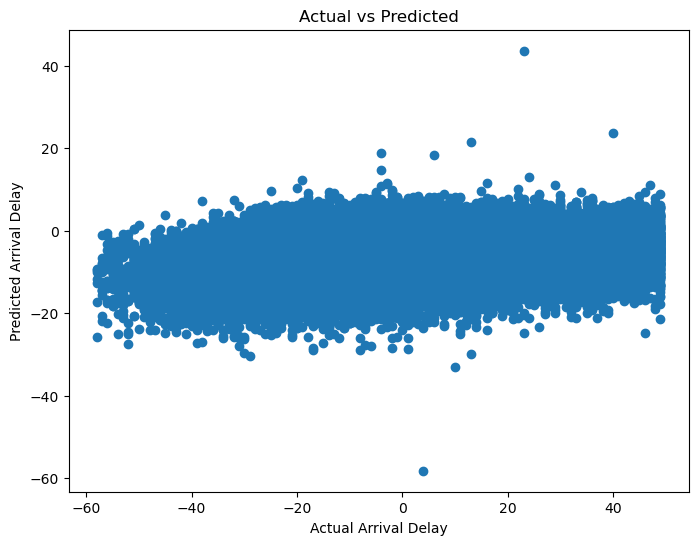

In [74]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_test_pred)
plt.xlabel("Actual Arrival Delay")
plt.ylabel("Predicted Arrival Delay")
plt.title("Actual vs Predicted")
plt.show()

In [76]:
residuals = y_test - y_test_pred

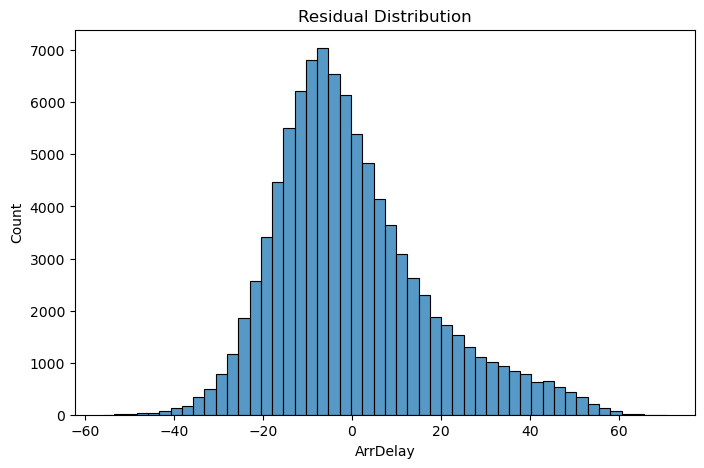

In [77]:
plt.figure(figsize=(8,5))

sns.histplot(residuals, bins=50)

plt.title("Residual Distribution")

plt.show()

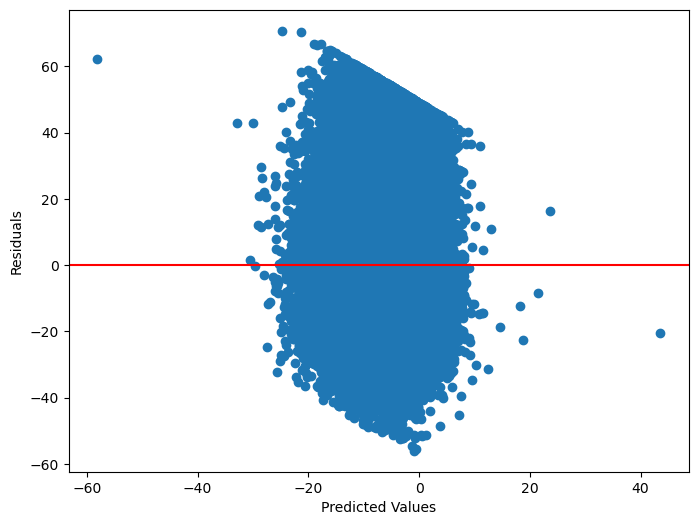

In [78]:
plt.figure(figsize=(8,6))

plt.scatter(y_test_pred, residuals)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.show()

In [79]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

importance = importance.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

importance

,Feature,Coefficient
1631,ArrTimeBlk_2300-2359,2.915615e+01
1630,ArrTimeBlk_2200-2259,2.833924e+01
1629,ArrTimeBlk_2100-2159,2.744668e+01
1628,ArrTimeBlk_2000-2059,2.644286e+01
1627,ArrTimeBlk_1900-1959,2.471063e+01
...,...,...
11,Cancelled,4.076184e-13
86,Origin_BQK,-1.509903e-13
14,Flights,3.902434e-14
12,Diverted,-1.607048e-14


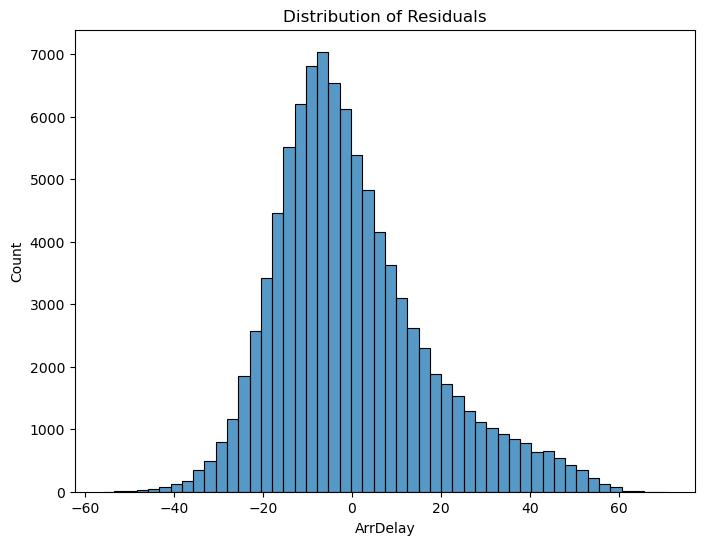

In [82]:
plt.figure(figsize=(8,6))

sns.histplot(residuals, bins=50)

plt.title("Distribution of Residuals")

plt.show()

In [85]:
mae = mean_absolute_error(y_test, y_test_pred)

mse = mean_squared_error(y_test, y_test_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_test_pred)
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 :", r2)

MAE : 13.484830111293101
MSE : 302.5593722292089
RMSE : 17.394233878765945
R2 : 0.06959260160732328


In [92]:
X.columns.to_list()

['Year',
 'Quarter',
 'Month',
 'DayofMonth',
 'DayOfWeek',
 'OriginStateFips',
 'OriginWac',
 'DestStateFips',
 'DestWac',
 'CRSDepTime',
 'CRSArrTime',
 'Cancelled',
 'Diverted',
 'CRSElapsedTime',
 'Flights',
 'Distance',
 'DistanceGroup',
 'Day',
 'DepHour',
 'ArrHour',
 'Reporting_Airline_AS',
 'Reporting_Airline_B6',
 'Reporting_Airline_DL',
 'Reporting_Airline_F9',
 'Reporting_Airline_G4',
 'Reporting_Airline_MQ',
 'Reporting_Airline_NK',
 'Reporting_Airline_OH',
 'Reporting_Airline_OO',
 'Reporting_Airline_UA',
 'Reporting_Airline_WN',
 'Reporting_Airline_YX',
 'IATA_CODE_Reporting_Airline_AS',
 'IATA_CODE_Reporting_Airline_B6',
 'IATA_CODE_Reporting_Airline_DL',
 'IATA_CODE_Reporting_Airline_F9',
 'IATA_CODE_Reporting_Airline_G4',
 'IATA_CODE_Reporting_Airline_MQ',
 'IATA_CODE_Reporting_Airline_NK',
 'IATA_CODE_Reporting_Airline_OH',
 'IATA_CODE_Reporting_Airline_OO',
 'IATA_CODE_Reporting_Airline_UA',
 'IATA_CODE_Reporting_Airline_WN',
 'IATA_CODE_Reporting_Airline_YX',
 'Ori